<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Logistic Regression — Breast Cancer Diagnosis</h1>
<p align="center"><i>Notebook 1 — Exploratory data analysis: do these features actually separate the classes?</i></p>

---

## 1. The Data Drives the Model, Not the Other Way Around

It is tempting to jump straight to fitting a model and start tuning hyperparameters. Resist
that urge. **No amount of hyperparameter tuning, regularization, or clever solver choice will
rescue a model whose input features simply don't separate the classes.** Logistic regression,
in particular, draws a single (linear, in feature space) decision boundary — if `benign` and
`malignant` points are hopelessly intermixed in feature space, that boundary cannot exist no
matter how we fit it.

So before writing a single line of modeling code, we ask three questions of the data:

1. **Do individual features look different between the two classes?** (univariate view)
2. **Do combinations of features separate the classes even better than any single feature?**
   (multivariate view)
3. **Are features redundant with each other**, i.e. do several columns carry almost the same
   information? (correlation view — this matters for interpreting coefficients later, and for
   whether regularization / dimensionality reduction would help)

This notebook works through each in turn. Every plot below closes with a short note on *why*
it matters for the logistic regression model we build in Notebook 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

df = pd.read_csv("data/breast_cancer_clean.csv")
print(df.shape)
df.head(3)

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant


In [2]:
df["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Univariate View: Violin / Box Plots by Diagnosis

We start with three of the most clinically intuitive features — `radius_mean`,
`texture_mean`, and `concavity_mean` — and look at their distribution **within each
diagnosis class**. A violin plot shows the full shape of the distribution (via a
kernel density estimate) with a box plot overlaid for the median and quartiles.

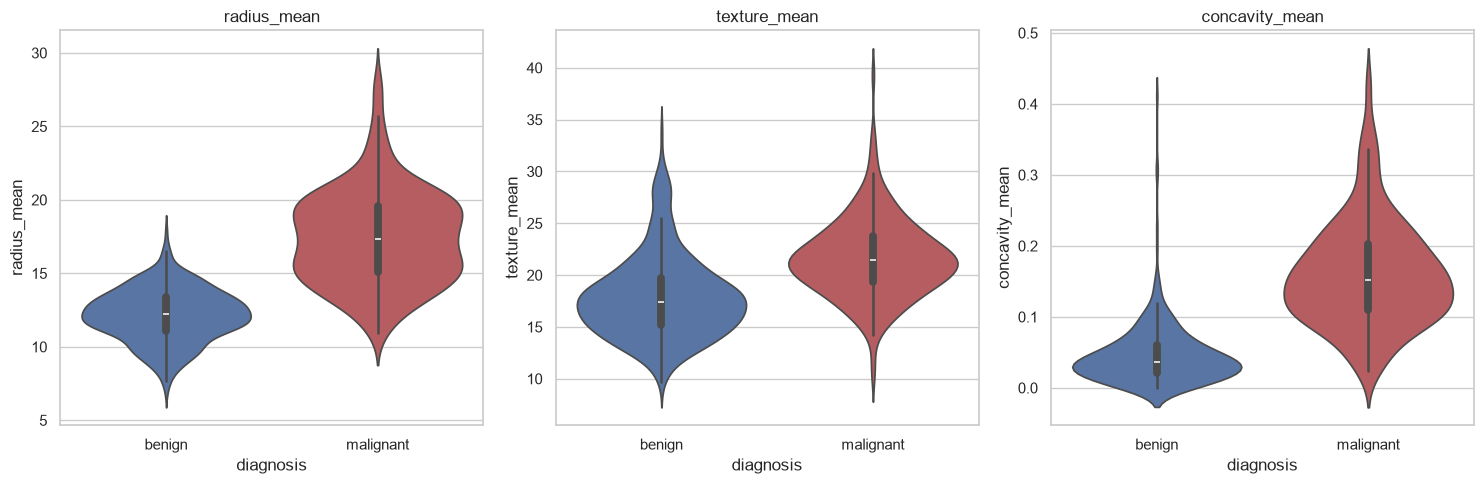

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, ["radius_mean", "texture_mean", "concavity_mean"]):
    sns.violinplot(data=df, x="diagnosis", y=feature, ax=ax, hue="diagnosis",
                    order=["benign", "malignant"], hue_order=["benign", "malignant"],
                    palette={"benign": "#4C72B0", "malignant": "#C44E52"}, legend=False)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**What this tells us:**

- `radius_mean` and `concavity_mean` show a clear, large shift between benign and malignant —
  malignant tumors have visibly larger, more concave nuclei, consistent with the clinical
  intuition from Notebook 0. These two features alone already carry substantial predictive
  signal.
- `texture_mean` shows a shift too, but the two distributions overlap much more heavily. It
  will likely still help the model, but on its own it is a much weaker discriminator.
- The fact that these single-feature distributions already separate reasonably well is a
  strong good sign for logistic regression: it means a **linear combination** of features
  (which is all logistic regression can express, before the sigmoid) has real signal to work
  with — we are not asking it to find structure that isn't there.

## 3. Multivariate View: Pairplot of the Most Discriminative Features

A single feature is rarely the whole story. Next we find the four `_mean` features with the
**strongest absolute correlation to the diagnosis** (encoded 0 = benign, 1 = malignant) and
look at all pairwise relationships between them, colored by diagnosis.

In [4]:
mean_cols = [c for c in df.columns if c.endswith("_mean")]
diagnosis_bin = df["diagnosis"].map({"benign": 0, "malignant": 1})

corr_with_target = df[mean_cols].corrwith(diagnosis_bin).abs().sort_values(ascending=False)
print(corr_with_target)

top4 = corr_with_target.head(4).index.tolist()
print("\nTop 4 most-correlated _mean features:", top4)

concave_points_mean       0.776614
perimeter_mean            0.742636
radius_mean               0.730029
area_mean                 0.708984
concavity_mean            0.696360
compactness_mean          0.596534
texture_mean              0.415185
smoothness_mean           0.358560
symmetry_mean             0.330499
fractal_dimension_mean    0.012838
dtype: float64

Top 4 most-correlated _mean features: ['concave_points_mean', 'perimeter_mean', 'radius_mean', 'area_mean']


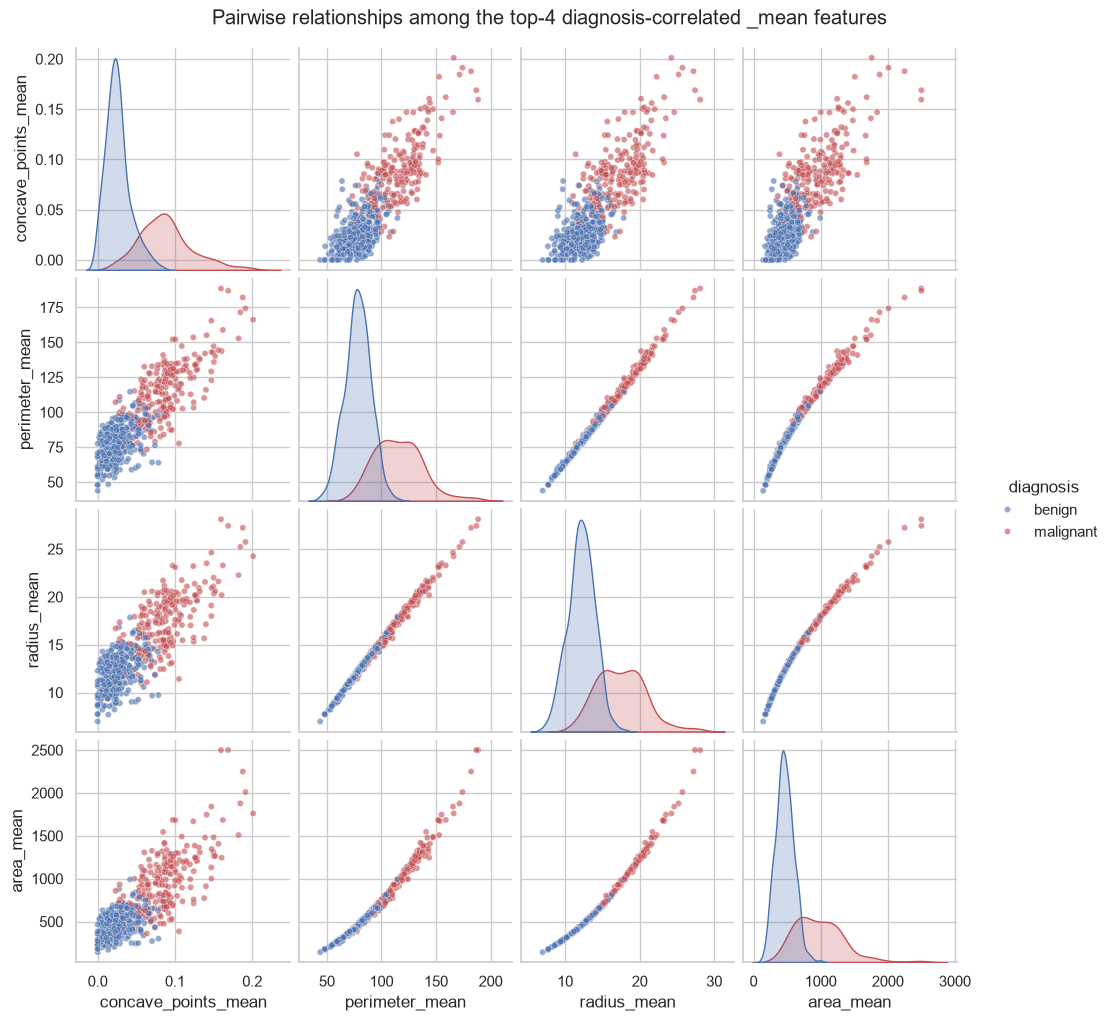

In [5]:
pairplot_df = df[top4 + ["diagnosis"]]
g = sns.pairplot(
    pairplot_df, hue="diagnosis", hue_order=["benign", "malignant"],
    palette={"benign": "#4C72B0", "malignant": "#C44E52"},
    diag_kind="kde", plot_kws={"alpha": 0.6, "s": 20},
)
g.fig.suptitle("Pairwise relationships among the top-4 diagnosis-correlated _mean features", y=1.02)
plt.show()

**What this tells us:**

- Along the diagonal, each feature's own KDE (repeated from the violin plots, but now for all
  four top features) shows how cleanly it separates the classes on its own.
- Off-diagonal scatter panels show that **pairs** of these features separate the classes even
  more cleanly than either feature alone — the two color clusters are visibly more distinct
  when viewed in 2D. This is exactly the kind of multivariate structure a logistic regression
  model (with 30 input dimensions, not just 2) can exploit through its learned coefficients.
- Because several of these top features are highly correlated with each other (not just with
  the diagnosis — see the heatmap next), the *marginal* value of adding all of them together
  is somewhat less than adding four independent features would be. Still, the visible
  separation confirms these are the "load-bearing" features for the model.

## 4. Correlation Heatmap: Redundant Information Across `_mean` / `_se` / `_worst`

Recall from Notebook 0 that each of the 10 base measurements is summarized three ways
(`_mean`, `_se`, `_worst`). Since `_worst` is computed from the same underlying nuclei as
`_mean`, we expect strong correlation *within* a measurement across its three summary
statistics, and also strong correlation *across* related measurements (e.g. `radius`,
`perimeter`, and `area` are all, geometrically, different transformations of "how big is the
nucleus").

**The formula behind every cell of the heatmap.** `df.corr()` computes the **Pearson
correlation coefficient** for every pair of features. For two features $x$ and $y$ measured
across $n$ patients:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\;\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}} = \frac{\text{cov}(x, y)}{\sigma_x\,\sigma_y}$$

i.e. the covariance between $x$ and $y$, normalized by each feature's own standard
deviation. That normalization is what keeps $r_{xy}$ confined to $[-1, 1]$ regardless of the
features' original units or scale (so `radius_mean` in mm and `area_mean` in mm² are still
directly comparable on the same heatmap):

- $r_{xy} = 1$: a perfect positive linear relationship (as $x$ rises, $y$ rises
  proportionally).
- $r_{xy} = -1$: a perfect negative linear relationship.
- $r_{xy} = 0$: no *linear* relationship (a strong nonlinear relationship can still hide
  behind $r_{xy} \approx 0$ — correlation only ever measures the linear part of the
  association).

Let's check with a correlation heatmap across all 30 features.

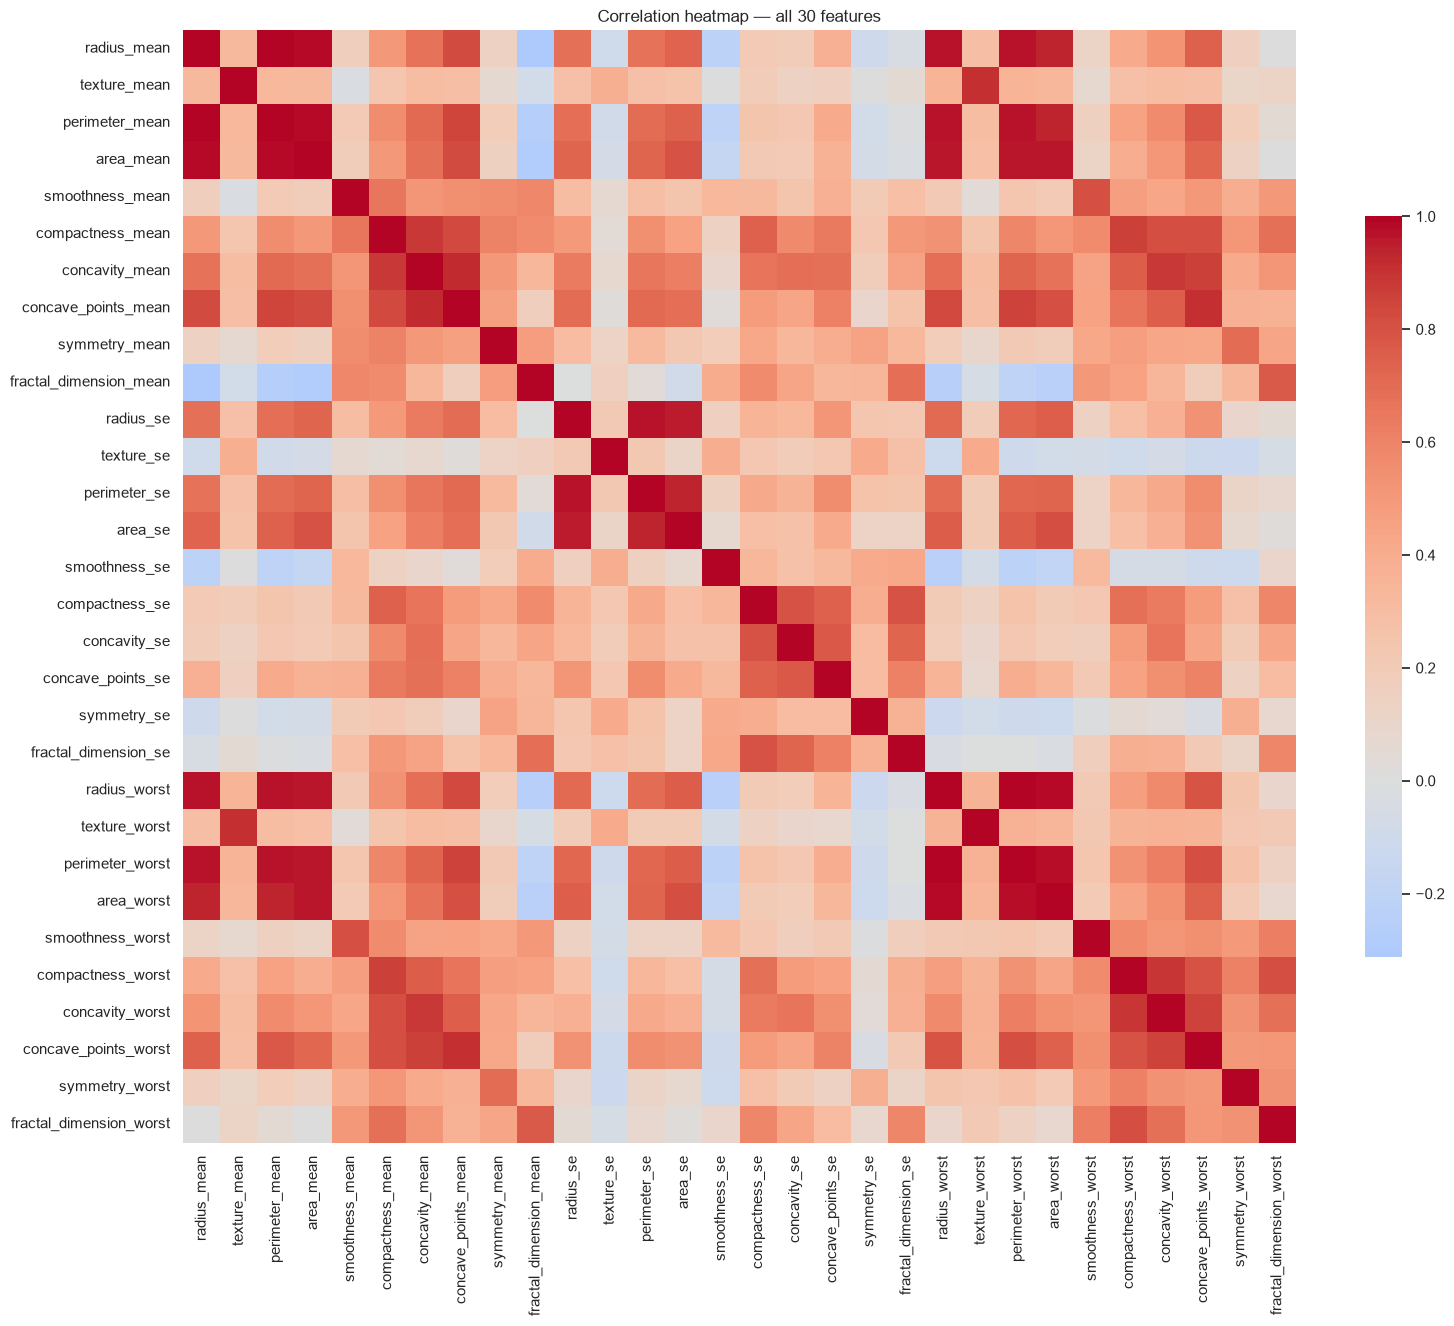

In [6]:
feature_cols = [c for c in df.columns if c != "diagnosis"]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlation heatmap — all 30 features")
plt.tight_layout()
plt.show()

**What this tells us:**

- Large dark-red blocks appear along the `radius` / `perimeter` / `area` triplet (for
  `_mean`, `_se`, and `_worst` alike) — these are, geometrically, near-duplicate information:
  perimeter and area are both deterministic functions of radius for a roughly circular shape.
  Correlations here are frequently above 0.95.
- The `_mean` and `_worst` versions of the *same* base measurement (e.g. `radius_mean` vs.
  `radius_worst`) are also strongly correlated, since `_worst` is derived from the same
  underlying set of nuclei as `_mean`.
- **Why this matters for the model in Notebook 3:** highly correlated (multicollinear)
  features don't break logistic regression's predictions, but they do make individual
  **coefficients** harder to interpret in isolation — the model can "trade" weight between two
  redundant features somewhat arbitrarily. This is also precisely the situation where **L2
  (ridge) regularization** helps: it shrinks and stabilizes coefficients spread across
  correlated features rather than letting any single one explode. We revisit this trade-off
  explicitly when discussing the `penalty` and `C` hyperparameters in Notebook 3.

## 5. Interactive 3D View: Three Strongly-Separating Features

A static 2D plot can only show so much. Using `plotly`, we can build an interactive 3D
scatter of three strongly-separating `_worst` features and rotate it to inspect how cleanly a
plane could, in principle, separate the two classes.

In [7]:
fig = px.scatter_3d(
    df, x="radius_worst", y="concavity_worst", z="texture_worst",
    color="diagnosis", color_discrete_map={"benign": "#4C72B0", "malignant": "#C44E52"},
    opacity=0.7, title="3D view: radius_worst vs. concavity_worst vs. texture_worst",
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=650)
fig.show()

**What this tells us:** even with only three of the thirty available features, the two
classes occupy visibly different regions of this 3D space, with malignant cases clustering
toward higher `radius_worst` and `concavity_worst`. Logistic regression will effectively try
to draw a (hyper-)plane through spaces like this one, generalized across all 30 dimensions
simultaneously — the more cleanly separated the classes already look in a handful of raw
features, the easier that job will be.

## 6. Parallel Coordinates: Many Features at Once

Parallel coordinates plots let us look at several features simultaneously by drawing one
axis per feature and one connected line per patient. Lines that follow visibly different
paths for benign vs. malignant patients indicate the feature set, taken together,
discriminates well.

In [8]:
pc_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean",
               "smoothness_mean", "concavity_mean", "concave_points_mean"]

pc_df = df[pc_features].copy()
pc_df["diagnosis_code"] = df["diagnosis"].map({"benign": 0, "malignant": 1})

fig = px.parallel_coordinates(
    pc_df, color="diagnosis_code", dimensions=pc_features,
    color_continuous_scale=[(0.0, "#4C72B0"), (1.0, "#C44E52")],
    title="Parallel coordinates across key _mean features (blue=benign, red=malignant)",
)
fig.update_layout(height=550)
fig.show()

**What this tells us:** benign patients (blue) trace a fairly tight, low-value band
across most axes, while malignant patients (red) fan out toward higher values on
`concavity_mean`, `concave_points_mean`, and `area_mean` in particular. The clearest visual
separation in the fan happens on the concavity-related axes — consistent with the clinical
prior from Notebook 0 that boundary irregularity is one of the strongest signals of
malignancy. `smoothness_mean` shows the least separation, suggesting it will contribute a
comparatively small, but not necessarily useless, share of the model's decision.

## Summary

- Individual features (`radius_mean`, `concavity_mean`) already show visible separation
  between benign and malignant — a good sign that a linear decision boundary (what logistic
  regression draws) is a reasonable modeling choice for this problem.
- Multivariate views (pairplot, 3D scatter, parallel coordinates) show the separation
  sharpens further when features are combined — exactly what a multi-feature logistic
  regression model is built to exploit.
- The correlation heatmap flags substantial redundancy across `_mean`/`_worst` versions of
  the same measurement and across geometrically related measurements (`radius`/`perimeter`/
  `area`). This foreshadows why L2 regularization and feature scaling both matter once we
  train the model.
- Next up (Notebook 2): encode the target, scale the features, split into train/test, and
  apply SMOTE to the training split only.